In [157]:
import splitfolders
import os
import sys
from pathlib import Path
import shutil
from dotenv import load_dotenv
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import tensorflow as tf 
from PIL import Image

notebook_path = Path.cwd()
project_root = notebook_path.parent
if str(project_root) not in sys.path: 
    sys.path.append(str(project_root))

from src.model.config import BATCH_SIZE, RANDOM_STATE, IMG_SIZE
from src.data_ops.load_data import split_data, del_broken_images, get_data

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Splitting and preparing the data: 

In [ ]:
split_data()
del_broken_images(data_path='../data_split/')

Copying files: 2395 files [00:00, 8039.43 files/s]

Data split succesfull


## Load the processed data 

In [159]:
CLASS_NAMES, train_dataset, val_dataset, test_dataset = get_data(data_path='../data_split/')

Found 1645 files belonging to 3 classes.
Found 353 files belonging to 3 classes.
Found 358 files belonging to 3 classes.


2026-03-07 14:57:34.990550: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-07 14:57:35.076192: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


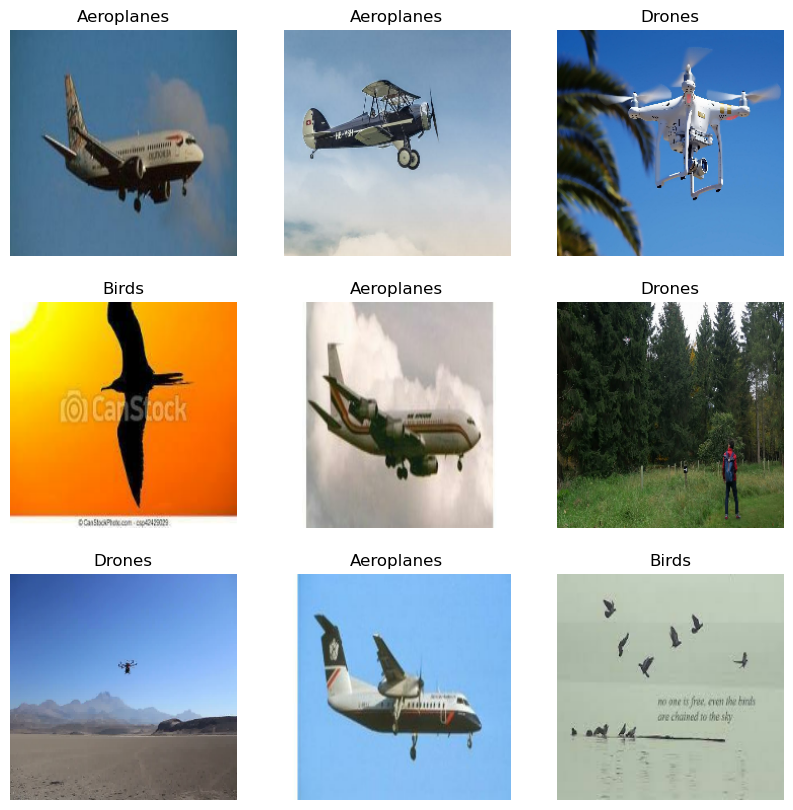

In [ ]:

plt.figure(figsize=(10,10))
for imgs, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis("off")

Using prefetch for gpu optimization: 
- It loads and auguments pictures with CPU
- THen it passes the preload photos to GPU for training



## Data augumentation
For now minimal augumentation for baseline

In [161]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomZoom(0.1,0.3), 
    tf.keras.layers.RandomRotation(0.1)
])

2026-03-07 14:58:07.233886: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-07 14:58:07.562677: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


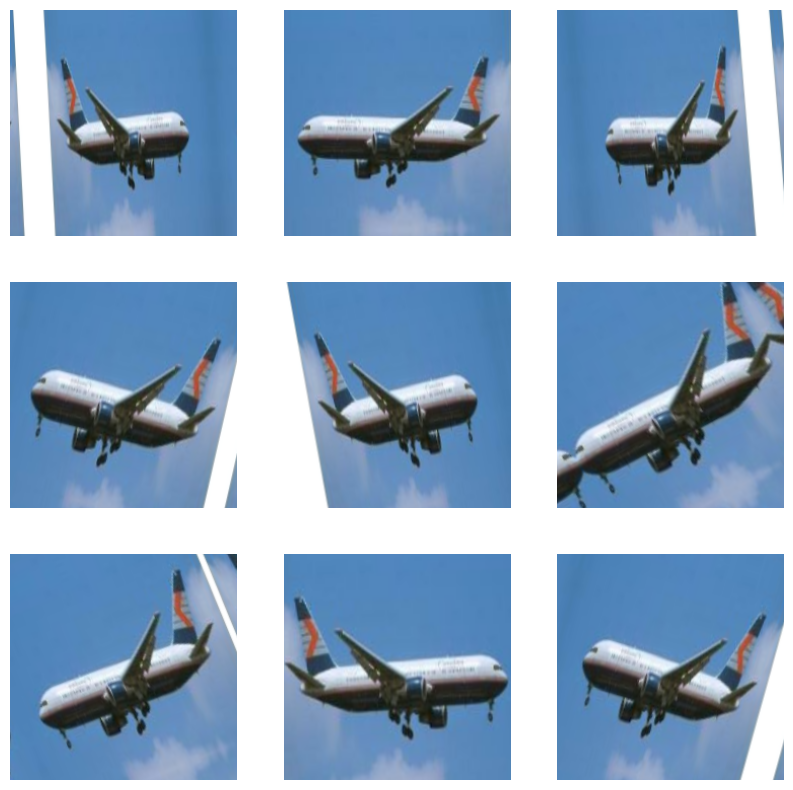

In [164]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input # Rescaling is happening here 

In [ ]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1) # In mobile 

## Loading the pretrained model without the final classification layer

In [101]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV3Large(input_shape = IMG_SHAPE,
                                               include_top = False,
                                               weights = 'imagenet')

In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch) #Passes the images through the model (without classification) for feature creation
print(feature_batch.shape)

(32, 7, 7, 960)


## Freezing the Convolution base 

In [103]:
base_model.trainable = False

In [169]:
base_model.summary()

Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_11[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_4[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation_20[0]… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu_19[0][0]    │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation_20[0]… │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_20[0][0]    │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 2,996,352 (11.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,996,352 (11.43 MB)

In [105]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 960)


In [106]:
prediction_layer = tf.keras.layers.Dense(3, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 3)


In [107]:
inputs = tf.keras.Input(shape = (224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training = False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [108]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         2,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999,235 (11.44 MB)

 Trainable params: 2,883 (11.26 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [109]:
len(model.trainable_variables)

2

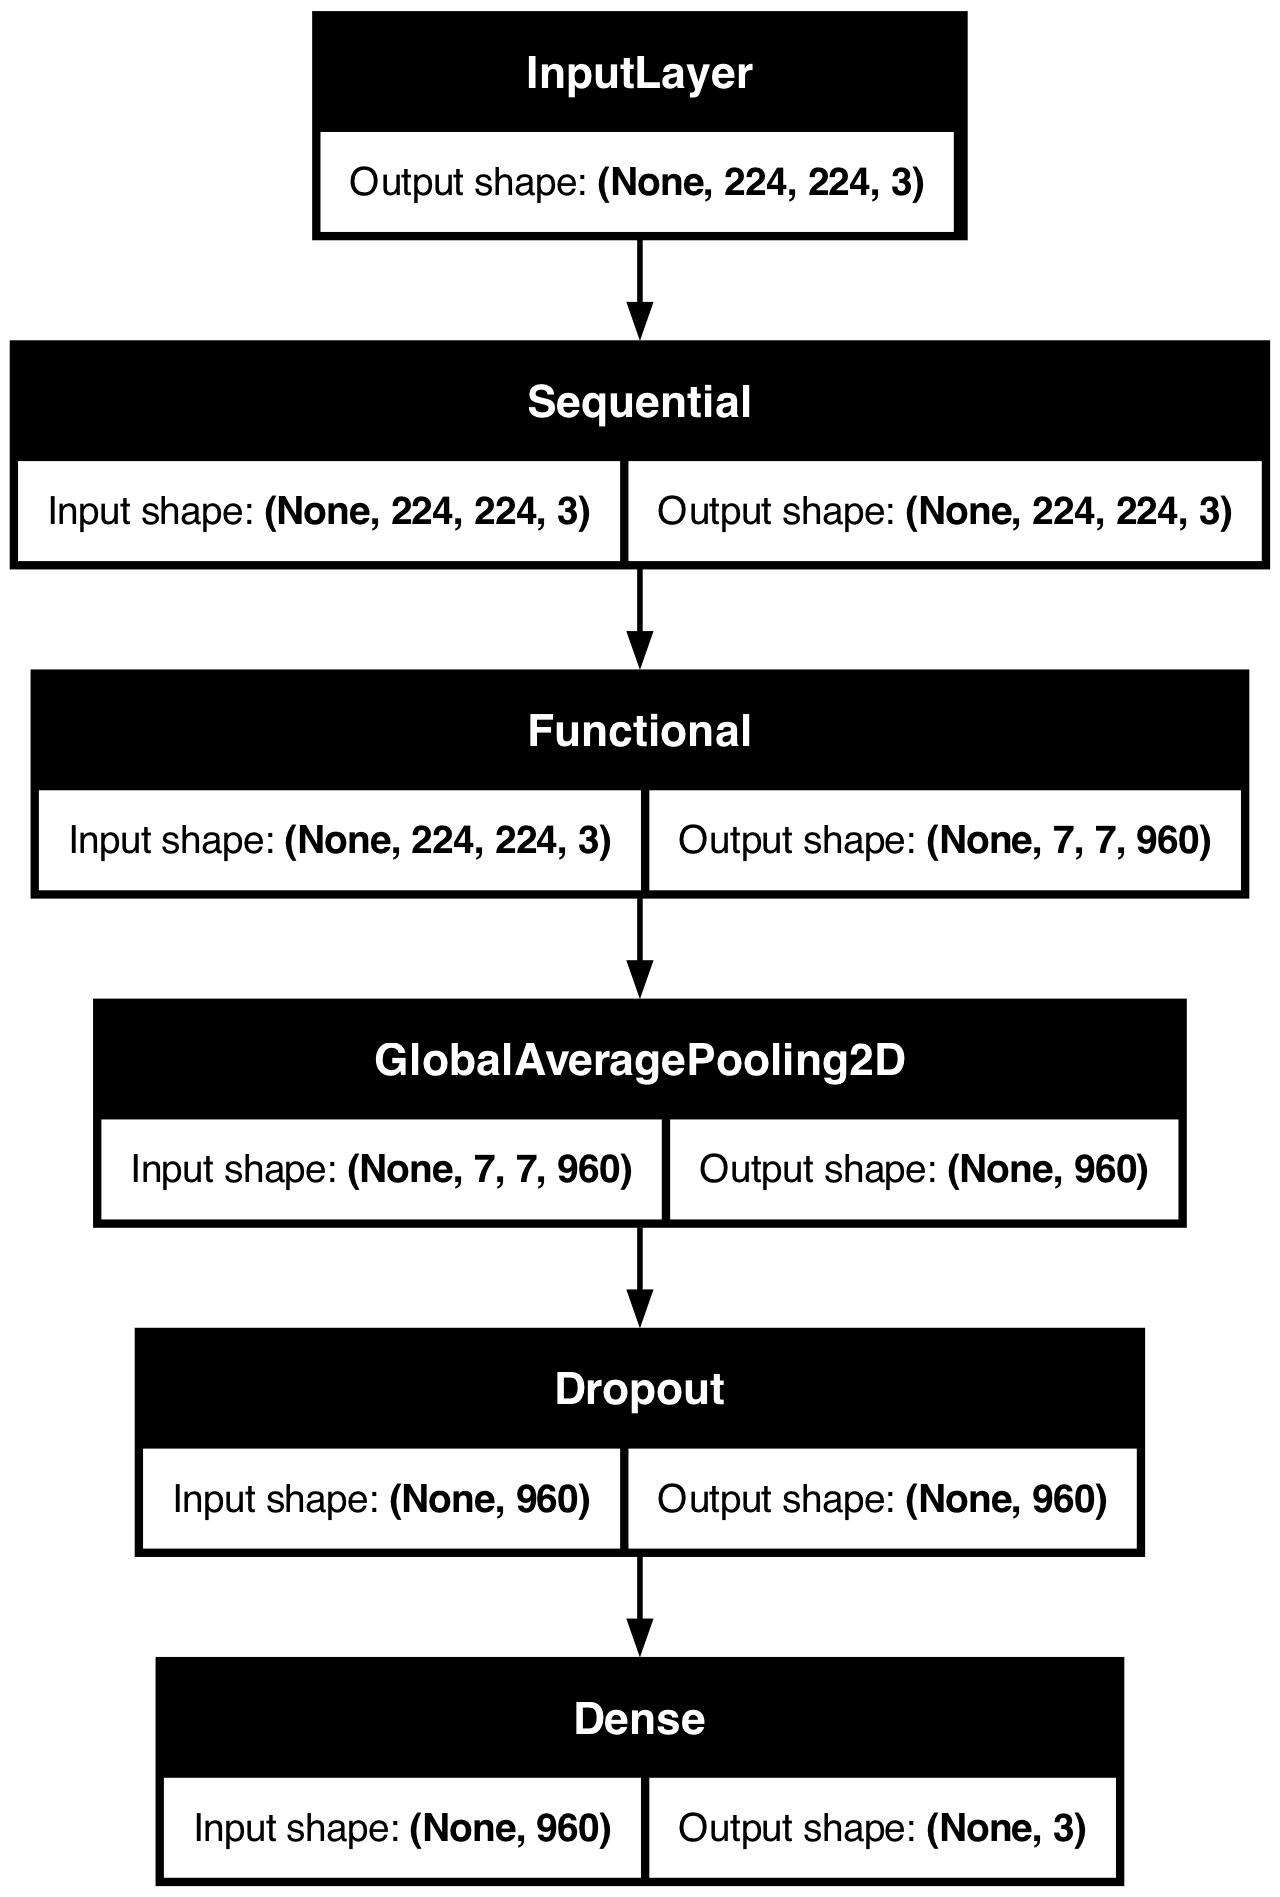

In [170]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [111]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # Changes the labels from integers to relatable format
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [112]:
initial_epochs = 10

loss0, accuracy0 = model.evaluate(val_dataset)

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step - accuracy: 0.3994 - loss: 1.2972


In [165]:
type(model)

keras.src.models.functional.Functional

In [113]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 1.30
initial accuracy: 0.40


In [114]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=val_dataset)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.4152 - loss: 1.3182 - val_accuracy: 0.5864 - val_loss: 0.9634
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.5520 - loss: 1.0390 - val_accuracy: 0.6487 - val_loss: 0.7826
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.6365 - loss: 0.8626 - val_accuracy: 0.7224 - val_loss: 0.6615
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.6778 - loss: 0.7537 - val_accuracy: 0.7507 - val_loss: 0.5868
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.7258 - loss: 0.6564 - val_accuracy: 0.8130 - val_loss: 0.5165
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.7526 - loss: 0.5958 - val_accuracy: 0.8215 - val_loss: 0.4718
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.7690 - loss: 0.5622 - val_accuracy: 0.8272 - val_loss: 0.4355
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.7951 - loss: 0.5112 - val_accuracy: 0

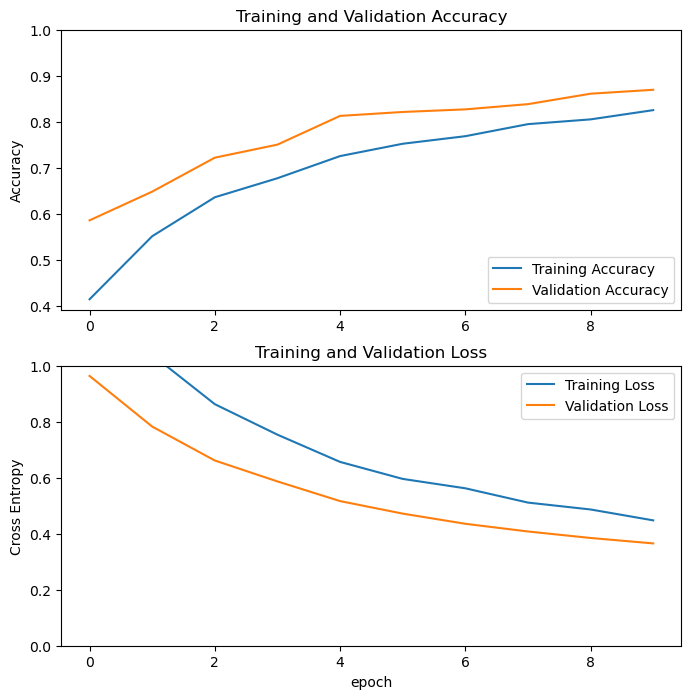

In [115]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## The first 10 Epochs of baseline model looks very promising. It looks like the learning rate is to little 

# More training: 

In [118]:
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9477 - loss: 0.1546 - val_accuracy: 0.9320 - val_loss: 0.1890
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9398 - loss: 0.1662 - val_accuracy: 0.9320 - val_loss: 0.1861
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.9404 - loss: 0.1661 - val_accuracy: 0.9320 - val_loss: 0.1859
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9483 - loss: 0.1582 - val_accuracy: 0.9348 - val_loss: 0.1860
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9447 - loss: 0.1592 - val_accuracy: 0.9377 - val_loss: 0.1840
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9435 - loss: 0.1561 - val_accuracy: 0.9377 - val_loss: 0.1847
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9526 - loss: 0.1458 - val_accuracy: 0.9377 - val_loss: 0.1840
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9380 - loss: 0.1594 - val_accuracy: 0.

For tests i have decided to run the model for 50 epochs. 
Even without the class weighing and with unfreezing only the final layer of the model I got a very good performance on the validation set 

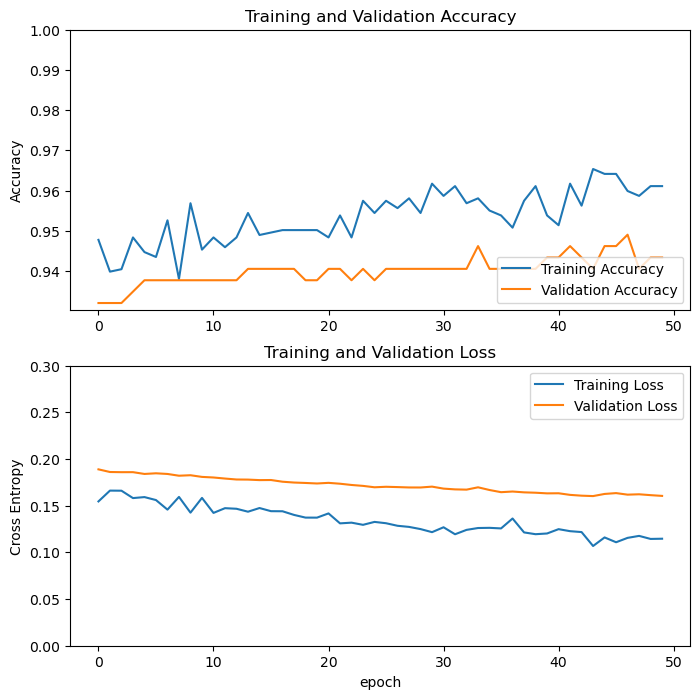

In [136]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,0.3])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
y_true = []
for images, labels in val_dataset:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

predictions = model.predict(val_dataset)

y_pred = np.argmax(predictions, axis=1)

 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step

2026-03-07 14:26:21.170187: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


              precision    recall  f1-score   support

           0       0.95      0.92      0.93       151
           1       0.90      0.98      0.94        87
           2       0.97      0.95      0.96       115

    accuracy                           0.94       353
   macro avg       0.94      0.95      0.94       353
weighted avg       0.94      0.94      0.94       353



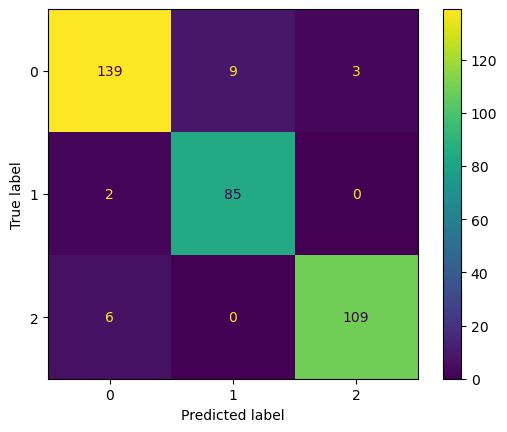

In [ ]:

import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Obliczamy macierz
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
print(classification_report(y_true, y_pred))

# The results on the confusion matrix are stunning. The model almost perfeclty separates different flying objects. However the 0.94 weighted accuracy can probably be further improved by unfreezing some of the layers and also retraining them 

### Saving the initial model 

In [145]:
model.save('model_v1.keras')

## Testing the encapsulated fuction of the first model 

In [245]:
from src.model.models import get_model_v1, early_stopping, lr_decay, checkpoint
from src.model.helpers import plot_history

In [233]:
model_2 = get_model_v1(learning_rate=0.001, dropout_rate=0.2)

In [236]:
history = model_2.fit(train_dataset,
                    epochs=40,
                    validation_data=val_dataset, 
                    callbacks=[early_stopping(5),
                               lr_decay()])

Epoch 1/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.7435 - loss: 0.6399 - val_accuracy: 0.8810 - val_loss: 0.3248 - learning_rate: 0.0010
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.8772 - loss: 0.3162 - val_accuracy: 0.8924 - val_loss: 0.2594 - learning_rate: 0.0010
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8985 - loss: 0.2592 - val_accuracy: 0.9037 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.9252 - loss: 0.2233 - val_accuracy: 0.9150 - val_loss: 0.2145 - learning_rate: 0.0010
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9331 - loss: 0.1918 - val_accuracy: 0.9150 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 6/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9368 - loss: 0.1841 - val_accuracy: 0.9178 - val_loss: 0.1882 - learning_rate: 0.0010
Epoch 7/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.9526 - loss: 0.1442 -

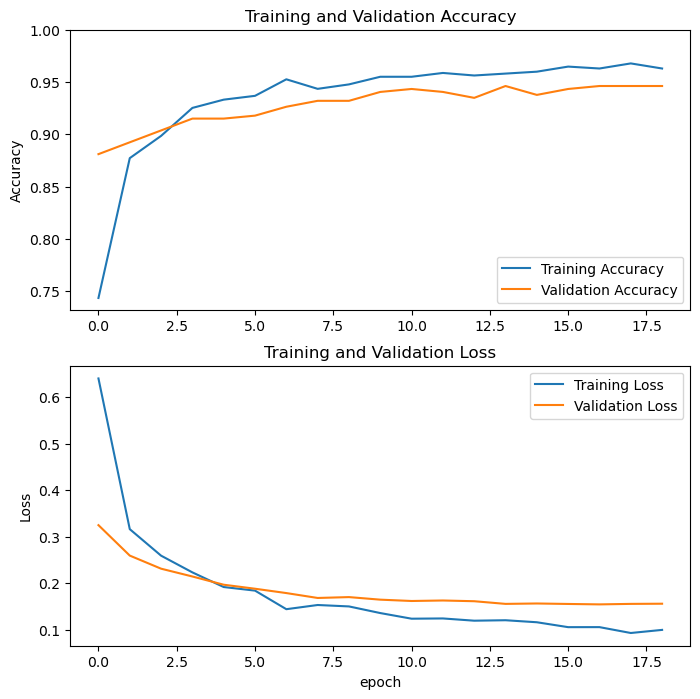

In [237]:
plot_history(history)

In [239]:
model_2.save_weights('../src/model/weights/model_v2.weights.h5')


After testing the Build model function i tested lower Learning rate and the model seems to converge around 14 epoch

base_model

In [240]:
from src.model.models import get_model_v2

In [261]:
model_3 = get_model_v2(fine_tune_at=100,learning_rate=0.0001/10, dropout_rate=0.2)

In [262]:
len(model_3.trainable_variables) #Check for unfreezing 

79

In [264]:
model_3.load_weights('../src/model/weights/model_v2.weights.h5')

In [265]:

history_3 = model_3.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=[#early_stopping(5),
                    checkpoint('../src/model/weights/model_v3.weights.h5'),])



Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8512 - loss: 0.3648
Epoch 1: val_accuracy improved from None to 0.94334, saving model to ../src/model/weights/model_v3.weights.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 42s 483ms/step - accuracy: 0.8632 - loss: 0.3329 - val_accuracy: 0.9433 - val_loss: 0.1607
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.8726 - loss: 0.3112
Epoch 2: val_accuracy did not improve from 0.94334
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.8863 - loss: 0.2890 - val_accuracy: 0.9433 - val_loss: 0.1628
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9101 - loss: 0.2616
Epoch 3: val_accuracy did not improve from 0.94334
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - accuracy: 0.9137 - loss: 0.2485 - val_accuracy: 0.9433 - val_loss: 0.1606
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9183 - loss: 0.2198
Epoch 4: val_accuracy did not improve from 0.94334
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/st

In [294]:
from src.model.models import get_preds

In [295]:
y_true, predictions_3, proba_preds_3 = get_preds(val_dataset, model_3)

2026-03-08 18:48:38.632535: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


              precision    recall  f1-score   support

           0       0.95      0.93      0.94       151
           1       0.93      0.93      0.93        87
           2       0.95      0.97      0.96       115

    accuracy                           0.94       353
   macro avg       0.94      0.94      0.94       353
weighted avg       0.94      0.94      0.94       353



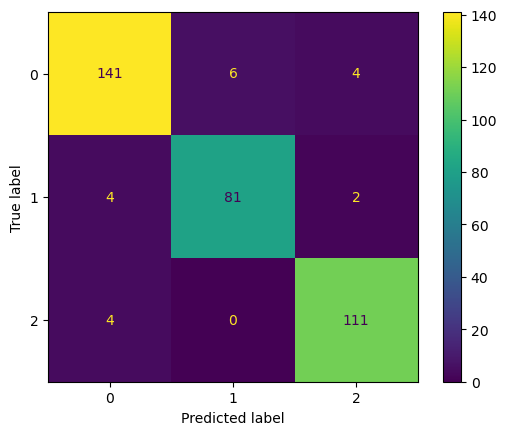

In [272]:
ConfusionMatrixDisplay.from_predictions(y_true, predictions_3)
print(classification_report(y_true, predictions_3))

The model performance didn't improve after unfreezing almost the half of the layers. It means that we are probably at the glass ceilling with the current data and architecture. The performance is well (weighted acuacy 0.94) Before the deployment and the final test set validation I will manually analyze the errors of the model on the validation set to see what pictures were the most problematic 

In [ ]:
cm_map = {
    0: 'Aeroplanes',
    1: 'Birds', 
    2: 'Drones'
}

mistakes_idx = np.where(y_true != predictions_3)
missed_preds =predictions_3[mistakes_idx]
missed_preds_nams =[cm_map[i] for i in predictions_3[mistakes_idx]] 
missed_probabilities = proba_preds_3[mistakes_idx]

all_images = []
all_labels = []

for images, labels in val_dataset: 
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())
all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
missed_images = all_images[mistakes_idx]

Because of only 20 bad predictions on validation set I can visualize and look at all of them on one plot

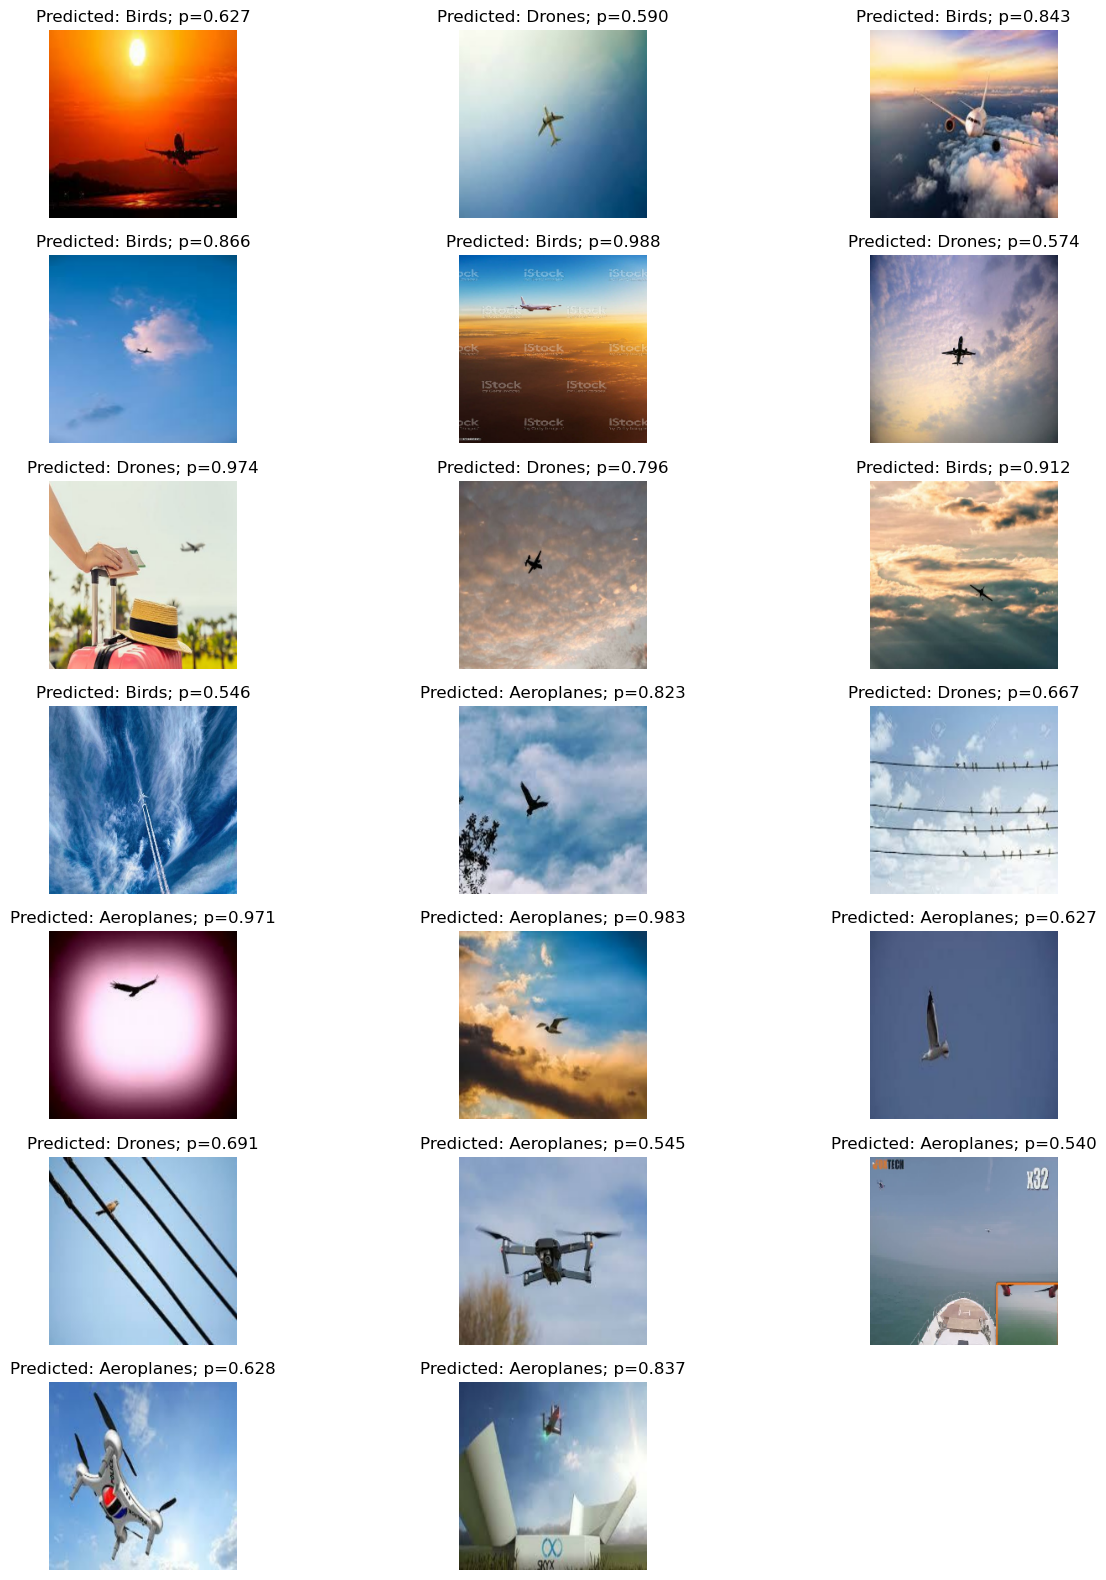

In [361]:
plt.figure(figsize=(15,20))
for i in range(len(missed_images)):
    x = (len(missed_images)+1)//3
    label = cm_map[missed_preds[i]]
    proba = missed_probabilities[i][missed_preds[i]]
    ax = plt.subplot(x, 3, i + 1)
    plt.imshow(missed_images[i].astype("uint8"))
    plt.title(f'Predicted: {label}; p={proba:.3f}')
    plt.axis("off")